In [1]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
     - -------------------------------------- 0.1/4.1 MB 3.2 MB/s eta 0:00:02
     --- ------------------------------------ 0.4/4.1 MB 3.7 MB/s eta 0:00:02
     -------- ------------------------------- 0.9/4.1 MB 7.0 MB/s eta 0:00:01
     -------------- ------------------------- 1.5/4.1 MB 8.9 MB/s eta 0:00:01
     --------------------- ------------------ 2.2/4.1 MB 9.9 MB/s eta 0:00:01
     -------------------------- ------------- 2.8/4.1 MB 10.4 MB/s eta 0:00:01
     --------------------------------- ------ 3.5/4.1 MB 11.0 MB/s eta 0:00:01
     --------------------------------- ------ 3.5/4.1 MB 9.7 MB/s eta 0:00:01
     ---------------------------------------  4.1/4.1 MB 10.5 MB/s eta 0:00:01
     ---------------------------------------- 4.1/4.1 MB 10.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchaudio to determine which version is 


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!pip -q install --upgrade pip
!pip -q install tqdm matplotlib pillow opencv-python
!pip -q install transformers accelerate

try:
    import pycocotools  # noqa
    print('pycocotools already available')
except Exception:
    !pip -q install pycocotools
    try:
        import pycocotools  # noqa
        print('pycocotools installed')
    except Exception:
        print('pycocotools kurulamadı. Windows için alternatif:')
        print('  !pip install pycocotools-windows')

ERROR: To modify pip, please run the following command:
d:\SAYZEK\Sayzek_models\.venv\Scripts\python.exe -m pip -q install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


pycocotools already available



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import random
import time
from dataclasses import dataclass

import numpy as np
import torch
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from PIL import Image

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

from transformers import DetrImageProcessor, DetrForObjectDetection

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch:', torch.__version__)
print('device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

d:\SAYZEK\Sayzek_models\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.5.1+cu121
device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 1) Dataset yolları

In [ ]:
# Dataset yolu
DATA_ROOT = r"D://SAYZEK//SAYZEK_COCO"

# Bu dataset yapısında yalnızca train klasörü ve train/_annotations.coco.json var.
# Val klasörü yoksa train içinden otomatik train/val split yapıp COCO json üretiriz.

import json

TRAIN_IMG_DIR = os.path.join(DATA_ROOT, 'train')
VAL_IMG_DIR = os.path.join(DATA_ROOT, 'val')  # varsa kullanılır; yoksa train ile aynı olacak

# Klasik COCO export yolları (train/val klasörleri + annotations/..)
TRAIN_ANN = os.path.join(DATA_ROOT, 'annotations', 'instances_train.json')
VAL_ANN = os.path.join(DATA_ROOT, 'annotations', 'instances_val.json')

# RoboFlow COCO export (tek klasör) yolu
ROBOFLOW_ANN = os.path.join(TRAIN_IMG_DIR, '_annotations.coco.json')
VAL_SPLIT = 0.2
SPLIT_SEED = 42

def _split_coco(ann_path: str, out_train_path: str, out_val_path: str, val_ratio: float = 0.2, seed: int = 42):
    with open(ann_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    images = list(data.get('images', []))
    rng = random.Random(seed)
    rng.shuffle(images)
    n_val = max(1, int(len(images) * val_ratio)) if len(images) > 1 else 0
    val_images = images[:n_val]
    train_images = images[n_val:]
    val_ids = {im['id'] for im in val_images}
    train_ids = {im['id'] for im in train_images}
    anns = list(data.get('annotations', []))
    val_anns = [a for a in anns if a.get('image_id') in val_ids]
    train_anns = [a for a in anns if a.get('image_id') in train_ids]

    def _write(out_path: str, imgs, annotations):
        out = dict(data)
        out['images'] = imgs
        out['annotations'] = annotations
        with open(out_path, 'w', encoding='utf-8') as wf:
            json.dump(out, wf)

    _write(out_train_path, train_images, train_anns)
    _write(out_val_path, val_images, val_anns)

# Yolları çözümle
if os.path.exists(TRAIN_ANN) and os.path.exists(VAL_ANN) and os.path.exists(TRAIN_IMG_DIR) and os.path.exists(VAL_IMG_DIR):
    print('Klasik COCO yapısı bulundu (train/val + annotations).')
else:
    assert os.path.exists(TRAIN_IMG_DIR), f'Train image klasörü bulunamadı: {TRAIN_IMG_DIR}'
    assert os.path.exists(ROBOFLOW_ANN), f'COCO json bulunamadı: {ROBOFLOW_ANN}'
    VAL_IMG_DIR = TRAIN_IMG_DIR
    split_dir = os.path.join(DATA_ROOT, '_splits')
    os.makedirs(split_dir, exist_ok=True)
    TRAIN_ANN = os.path.join(split_dir, 'instances_train.json')
    VAL_ANN = os.path.join(split_dir, 'instances_val.json')
    if not (os.path.exists(TRAIN_ANN) and os.path.exists(VAL_ANN)):
        _split_coco(ROBOFLOW_ANN, TRAIN_ANN, VAL_ANN, val_ratio=VAL_SPLIT, seed=SPLIT_SEED)
    print('RoboFlow COCO yapısı bulundu. Split dosyaları:', TRAIN_ANN, VAL_ANN)

for p in [TRAIN_IMG_DIR, VAL_IMG_DIR, TRAIN_ANN, VAL_ANN]:
    print(p, '->', 'OK' if os.path.exists(p) else 'MISSING')

assert os.path.exists(TRAIN_ANN) and os.path.exists(VAL_ANN), 'Annotation dosyaları bulunamadı'
assert os.path.exists(TRAIN_IMG_DIR) and os.path.exists(VAL_IMG_DIR), 'Image klasörleri bulunamadı'


RoboFlow COCO yapısı bulundu. Split dosyaları: D:\\SAYZEK\\SAYZEK_COCO\_splits\instances_train.json D:\\SAYZEK\\SAYZEK_COCO\_splits\instances_val.json
D:\\SAYZEK\\SAYZEK_COCO\train -> OK
D:\\SAYZEK\\SAYZEK_COCO\train -> OK
D:\\SAYZEK\\SAYZEK_COCO\_splits\instances_train.json -> OK
D:\\SAYZEK\\SAYZEK_COCO\_splits\instances_val.json -> OK


In [3]:
# COCO objeleri ve kategori eşlemeleri
coco_train = COCO(TRAIN_ANN)
coco_val = COCO(VAL_ANN)

cat_ids = coco_train.getCatIds()
cats = coco_train.loadCats(cat_ids)
cats = sorted(cats, key=lambda x: x['id'])
id2name = {c['id']: c['name'] for c in cats}
cat_id_list = [c['id'] for c in cats]

# DETR model head'i için sınıf sayısı (labels: 0..num_classes-1)
num_classes = len(cat_id_list)
cat_id_to_idx = {cid: i for i, cid in enumerate(cat_id_list)}
idx_to_cat_id = {i: cid for cid, i in cat_id_to_idx.items()}

print('num_classes:', num_classes)
print('first categories:', list(id2name.items())[:10])


loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
num_classes: 4
first categories: [(0, 'objects'), (1, 'IHA'), (2, 'drone'), (3, 'vehicle')]


In [5]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Dataset wrapper (COCO) -> DETR format
from torchvision.datasets import CocoDetection

image_processor = DetrImageProcessor.from_pretrained('facebook/detr-resnet-50')

class DetrCocoDataset(CocoDetection):
    def __init__(self, img_folder, ann_file, processor: DetrImageProcessor, train: bool, cat_id_to_idx: dict[int, int]):
        super().__init__(img_folder, ann_file)
        self.processor = processor
        self.train = train
        self.cat_id_to_idx = cat_id_to_idx

    def __getitem__(self, idx):
        img, target = super().__getitem__(idx)
        image_id = self.ids[idx]
        # DETR eğitimi için category_id değerlerini 0..num_classes-1 aralığına map'liyoruz
        mapped_target = []
        for ann in target:
            ann2 = dict(ann)
            if 'category_id' in ann2:
                ann2['category_id'] = int(self.cat_id_to_idx[int(ann2['category_id'])])
            mapped_target.append(ann2)

        encoding = self.processor(
            images=img,
            annotations={'image_id': image_id, 'annotations': mapped_target},
            return_tensors='pt'
        )
        pixel_values = encoding['pixel_values'].squeeze(0)
        labels = encoding['labels'][0]
        return pixel_values, labels

def detr_collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors='pt')
    return {
        'pixel_values': encoding['pixel_values'],
        'pixel_mask': encoding['pixel_mask'],
        'labels': labels
    }

train_ds = DetrCocoDataset(TRAIN_IMG_DIR, TRAIN_ANN, image_processor, train=True, cat_id_to_idx=cat_id_to_idx)
val_ds = DetrCocoDataset(VAL_IMG_DIR, VAL_ANN, image_processor, train=False, cat_id_to_idx=cat_id_to_idx)

BATCH_SIZE = 4
NUM_WORKERS = 0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=detr_collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=detr_collate_fn)

print('train batches:', len(train_loader), 'val batches:', len(val_loader))


loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
train batches: 1798 val batches: 450


In [ ]:
%pip install timm

In [7]:
!pip install --upgrade transformers accelerate


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import torch
from transformers import DetrForObjectDetection

# Sınıf sayısı (Önceki adımlardan gelmeli)
# Eğer num_classes değişkeni silindiyse tekrar tanımlayın:
# num_classes = 4 

print("Model temiz bir şekilde yükleniyor...")

model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
    # BU İKİSİ BİRLİKTE OLMALI:
    low_cpu_mem_usage=False, 
    device_map=None 
)

model.to(device)

# Modelin gerçekten yüklenip yüklenmediğini test edelim
# Eğer backbone ağırlıkları 0'a çok yakınsa veya hepsi aynıysa sorun devam ediyor demektir.
print("Backbone kontrolü yapılıyor...")
print(f"Backbone ilk katman ortalaması: {model.model.backbone.conv_encoder.model.conv1.weight.mean().item()}")

LR = 1e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 10

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

print('Model ve Optimizer HAZIR. O kırmızı uyarılar gitmiş olmalı.')

Model temiz bir şekilde yükleniyor...


d:\SAYZEK\Sayzek_models\.venv\Lib\site-packages\torch\nn\modules\module.py:2400: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
d:\SAYZEK\Sayzek_models\.venv\Lib\site-packages\torch\nn\modules\module.py:2400: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
d:\SAYZEK\Sayzek_models\.venv\Lib\site-packages\torch\nn\modules\module.py:2400: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-

Backbone kontrolü yapılıyor...
Backbone ilk katman ortalaması: -0.0004950660513713956
Model ve Optimizer HAZIR. O kırmızı uyarılar gitmiş olmalı.


In [6]:
@torch.no_grad()
def evaluate_coco_map_detr(model, coco_gt: COCO, img_dir: str, processor: DetrImageProcessor, score_thresh: float = 0.0, max_images: int | None = None):
    model.eval()
    img_ids = coco_gt.getImgIds()
    if max_images is not None:
        img_ids = img_ids[:max_images]

    results = []
    for image_id in img_ids:
        img_info = coco_gt.loadImgs([image_id])[0]
        img_path = os.path.join(img_dir, img_info['file_name'])
        image = Image.open(img_path).convert('RGB')

        inputs = processor(images=image, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model(**inputs)
        # post-process to absolute boxes
        target_sizes = torch.tensor([image.size[::-1]], device=device)  # (h, w)
        processed = processor.post_process_object_detection(outputs, threshold=score_thresh, target_sizes=target_sizes)[0]

        boxes = processed['boxes'].detach().cpu().numpy()  # xyxy
        scores = processed['scores'].detach().cpu().numpy()
        labels = processed['labels'].detach().cpu().numpy()

        for box, score, label in zip(boxes, scores, labels):
            x1, y1, x2, y2 = box.tolist()
            w = max(0.0, x2 - x1)
            h = max(0.0, y2 - y1)
            results.append({
                'image_id': int(image_id),
                'category_id': int(cat_id_list[int(label)]) if int(label) < len(cat_id_list) else int(cat_id_list[-1]),
                'bbox': [float(x1), float(y1), float(w), float(h)],
                'score': float(score)
            })

    if len(results) == 0:
        return {'AP': 0.0, 'AP50': 0.0, 'AP75': 0.0}

    coco_dt = coco_gt.loadRes(results)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    stats = coco_eval.stats
    return {
        'AP': float(stats[0]),
        'AP50': float(stats[1]),
        'AP75': float(stats[2])
    }

def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    running_loss = 0.0
    n = 0
    for batch in loader:
        pixel_values = batch['pixel_values'].to(device)
        pixel_mask = batch['pixel_mask'].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch['labels']]

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
            loss = outputs.loss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += float(loss.item())
        n += 1
    return running_loss / max(1, n)

In [9]:
!pip install scipy

     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------------ ------------------------- 20.5/60.8 kB 222.6 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/60.8 kB 393.8 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 404.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/38.7 MB ? eta -:--:--
   ---------------------------------------- 0.1/38.7 MB 1.7 MB/s eta 0:00:24
   ---------------------------------------- 0.2/38.7 MB 2.1 MB/s eta 0:00:19
   ---------------------------------------- 0.4/38.7 MB 3.0 MB/s eta 0:00:13
    --------------------------------------- 0.8/38.7 MB 4.6 MB/s eta 0:00:09
   - -------------------------------------- 1.4/38.7 MB 6.2 MB/s eta 0:00:07
   -- ------------------------------------- 2.0/38.7 MB 7.5 MB/s eta 0:00:05
   -- ------------------------------------- 2.7/38.7 MB 8.5 MB/s eta 0:00:05
   --- ------------------------------------ 3.3/38.7 MB 9.2 MB/s eta 0:00:04
  


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import torch
import torch.optim as optim
from transformers import DetrForObjectDetection
from tqdm.auto import tqdm
import math
import sys
import gc

# --- 1. GPU ZORLAMA VE KONTROL ---
# NVIDIA kartını zorla seçiyoruz
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    gpu_name = torch.cuda.get_device_name(0)
    print("="*40)
    print(f"✅ HEDEF GPU: {gpu_name}")
    print(f"Durum: CUDA Aktif. İşlemler {gpu_name} üzerinde yapılacak.")
    print("="*40)
else:
    device = torch.device("cpu")
    print("❌ HATA: NVIDIA GPU algılanmadı! CPU kullanılıyor.")
    print("Lütfen GPU sürücülerinizi kontrol edin.")

# --- 2. BELLEK TEMİZLİĞİ (RAM SORUNU İÇİN) ---
torch.cuda.empty_cache()
gc.collect()

# --- 3. MODEL VE OPTIMIZER ---
# Modeli tekrar GPU'ya atadığımızdan emin olalım
model.to(device)

LR = 5e-5
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
EPOCHS = 5

print(f"Eğitim başlıyor... (Cihaz: {device})")

loss_history = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    
    # Progress bar
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch")
    
    for step, batch in enumerate(progress_bar):
        # VERİYİ GPU'YA TAŞIMA (Burada GPU kullanımı artmalı)
        pixel_values = batch['pixel_values'].to(device)
        pixel_mask = batch['pixel_mask'].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch['labels']]
        
        optimizer.zero_grad()
        
        # Forward Pass
        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
        loss = outputs.loss
        
        if torch.isnan(loss):
            print(f"\nUYARI: Batch {step} bozuk (NaN loss). Atlanıyor.")
            continue
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        optimizer.step()
        
        loss_val = loss.item()
        epoch_loss += loss_val
        progress_bar.set_postfix({"loss": f"{loss_val:.4f}"})

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1} Bitti -> Ort. Loss: {avg_loss:.4f}")
    
    # Checkpoint
    model.save_pretrained(f"./detr-rtx3050-epoch-{epoch+1}")

print("Eğitim tamamlandı.")

✅ HEDEF GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Durum: CUDA Aktif. İşlemler NVIDIA GeForce RTX 3050 Ti Laptop GPU üzerinde yapılacak.
Eğitim başlıyor... (Cihaz: cuda:0)


Epoch 1/5: 100%|██████████| 1798/1798 [20:47<00:00,  1.44batch/s, loss=1.1110]


Epoch 1 Bitti -> Ort. Loss: 1.4707


Epoch 2/5: 100%|██████████| 1798/1798 [19:36<00:00,  1.53batch/s, loss=2.0382]


Epoch 2 Bitti -> Ort. Loss: 1.1627


...

Epoch 3 Bitti -> Ort. Loss: 1.0944


Epoch 4/5: 100%|██████████| 1798/1798 [20:09<00:00,  1.49batch/s, loss=0.9565]


Epoch 4 Bitti -> Ort. Loss: 1.0313


Epoch 5/5: 100%|██████████| 1798/1798 [19:44<00:00,  1.52batch/s, loss=1.1125]

Epoch 5 Bitti -> Ort. Loss: 1.0246
Eğitim tamamlandı.


In [8]:
# Grafikler
epochs = list(range(1, len(history['train_loss']) + 1))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], marker='o')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history['AP'], marker='o', label='AP')
plt.plot(epochs, history['AP50'], marker='o', label='AP50')
plt.plot(epochs, history['AP75'], marker='o', label='AP75')
plt.title('COCO mAP')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

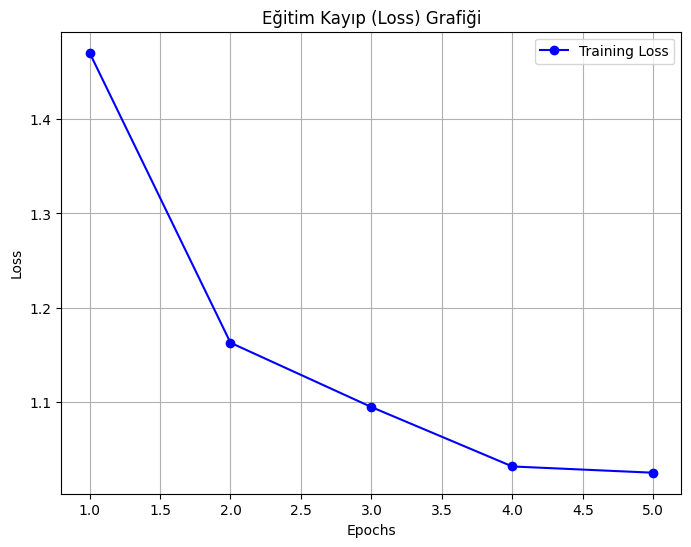

In [11]:
import matplotlib.pyplot as plt

# Eğer 'loss_history' değişkeni hafızada yoksa (Kernel resetlendiyse) 
# örnek olması için manuel tanımlayabiliriz. 
# Sizde varsa bu 'if' bloğu atlanacak.
if 'loss_history' not in globals():
    print("UYARI: loss_history bulunamadı. Önceki eğitim hücresi çalıştırılmamış veya Kernel sıfırlanmış.")
    print("Grafik çizilemiyor.")
else:
    # Loss Grafiğini Çiz
    epochs = range(1, len(loss_history) + 1)

    plt.figure(figsize=(8, 6))
    plt.plot(epochs, loss_history, 'b-o', label='Training Loss')
    plt.title('Eğitim Kayıp (Loss) Grafiği')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [15]:
!pip install CocoEvaluator

ERROR: Could not find a version that satisfies the requirement CocoEvaluator (from versions: none)
ERROR: No matching distribution found for CocoEvaluator

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from transformers.image_transforms import center_to_corners_format

def convert_to_xywh(boxes):
    xmin, ymin, xmax, ymax = boxes.unbind(1)
    return torch.stack((xmin, ymin, xmax - xmin, ymax - ymin), dim=1)

def evaluate(model, data_loader, device):
    model.eval()
    metric = CocoEvaluator(coco_val, iou_types=['bbox']) # coco_val değişkeni önceki adımlardan gelmeli
    
    print("Değerlendirme yapılıyor (Bu işlem biraz sürebilir)...")
    for batch in tqdm(data_loader, desc="Validation"):
        pixel_values = batch['pixel_values'].to(device)
        pixel_mask = batch['pixel_mask'].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch['labels']]
        
        with torch.no_grad():
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        orig_target_sizes = torch.stack([t["orig_size"] for t in labels], dim=0)
        results = image_processor.post_process_object_detection(outputs, target_sizes=orig_target_sizes)

        res = {target['image_id'].item(): output for target, output in zip(labels, results)}
        metric.update(res)

    metric.synchronize_between_processes()
    metric.accumulate()
    metric.summarize()
    return metric

# NOT: CocoEvaluator için ek kütüphane veya yardımcı fonksiyon gerekebilir.
# Eğer bu çok karmaşık gelirse, en pratiği "Görsel Tahmin" (Inference) yapmaktır.
# Yukarıdaki görsel tahmin kodunu (resim üzerine kutu çizen) çalıştırıp gözle kontrol etmek şu aşamada en iyisidir.

image: D:\\SAYZEK\\SAYZEK_COCO\train\01966_jpg.rf.31ed41251580b49b777418ac11810e40.jpg


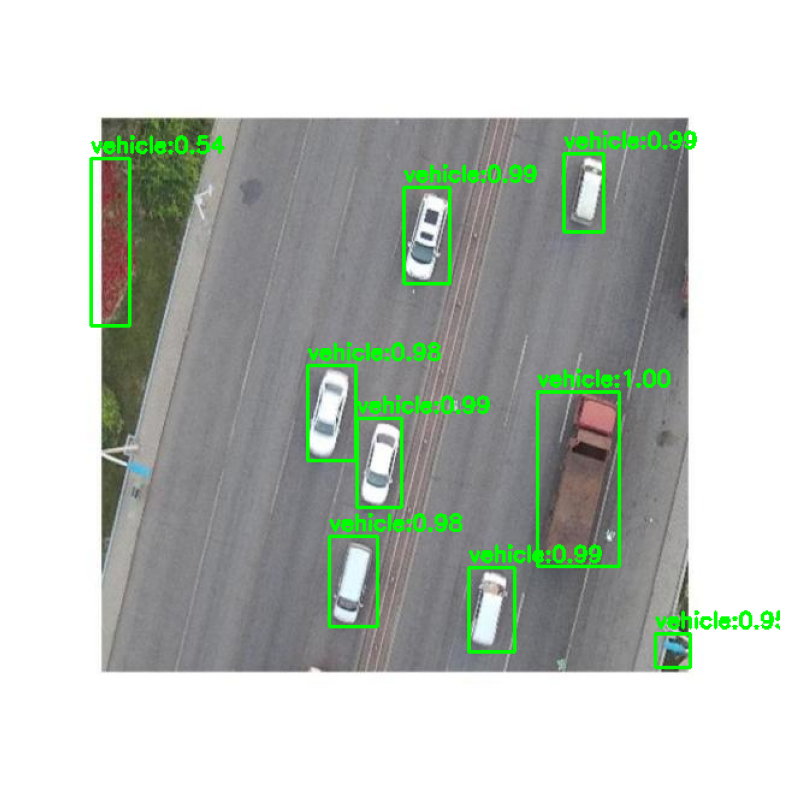

In [24]:
# Örnek tahmin görselleştirme
import cv2

def draw_boxes(image_bgr, boxes_xyxy, labels, scores, color=(0, 255, 0)):
    img = image_bgr.copy()
    for (x1, y1, x2, y2), lab, sc in zip(boxes_xyxy, labels, scores):
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        txt = f'{lab}:{sc:.2f}'
        cv2.putText(img, txt, (x1, max(0, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img

@torch.no_grad()
def predict_one(image_path, score_thresh=0.5):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    inputs = image_processor(images=image, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
    target_sizes = torch.tensor([image.size[::-1]], device=device)
    processed = image_processor.post_process_object_detection(outputs, threshold=score_thresh, target_sizes=target_sizes)[0]

    boxes = processed['boxes'].detach().cpu().numpy()
    scores = processed['scores'].detach().cpu().numpy()
    labels_idx = processed['labels'].detach().cpu().numpy()

    # label index -> coco category_id -> name
    cat_ids_pred = [cat_id_list[int(i)] for i in labels_idx]
    names = [id2name.get(int(cid), str(cid)) for cid in cat_ids_pred]

    img_bgr = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    vis = draw_boxes(img_bgr, boxes, names, scores)
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(vis_rgb)
    plt.axis('off')
    plt.show()

# Val'den rastgele bir resim seçip çiz
val_img_ids = coco_val.getImgIds()
img_id = random.choice(val_img_ids)
img_info = coco_val.loadImgs([img_id])[0]
img_path = os.path.join(VAL_IMG_DIR, img_info['file_name'])
print('image:', img_path)
predict_one(img_path, score_thresh=0.5)

## Notlar
- İlk eğitim aşaması tamamlandı. fine tuning aşaması başladı:

In [25]:
import torch
import torch.optim as optim
from tqdm.auto import tqdm
import math
import sys
import gc

# 1. Hazırlık ve Temizlik
torch.cuda.empty_cache()
gc.collect()

# Eğer önceki 5 epoch'tan kalan history yoksa boş başlat
if 'loss_history' not in globals():
    loss_history = []

# Learning Rate'i ince ayar için biraz daha düşürebiliriz (Opsiyonel, şimdilik sabit)
LR = 5e-5 
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Toplam eklenecek epoch
EXTRA_EPOCHS = 30
START_EPOCH = len(loss_history) + 1
END_EPOCH = START_EPOCH + EXTRA_EPOCHS

print(f"Eğitim Devam Ediyor: {START_EPOCH}. Epoch'tan {END_EPOCH-1}. Epoch'a kadar.")
print(f"Hedef GPU: {torch.cuda.get_device_name(0)}")

# 2. Eğitim Döngüsü
for epoch in range(START_EPOCH, END_EPOCH):
    model.train()
    epoch_loss = 0
    
    # Progress Bar
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{END_EPOCH-1}", unit="batch")
    
    for step, batch in enumerate(progress_bar):
        # GPU'ya taşıma
        pixel_values = batch['pixel_values'].to(device)
        pixel_mask = batch['pixel_mask'].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch['labels']]
        
        optimizer.zero_grad()
        
        # Forward Pass
        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
        loss = outputs.loss
        
        # NaN Kontrolü
        if torch.isnan(loss):
            print(f"\nUYARI: Batch {step} NaN loss verdi. Atlandı.")
            continue
            
        loss.backward()
        
        # Gradient Clipping (Patlamayı önler)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        
        optimizer.step()
        
        loss_val = loss.item()
        epoch_loss += loss_val
        progress_bar.set_postfix({"loss": f"{loss_val:.4f}"})

    # Epoch Sonu
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch} Tamamlandı -> Ort. Loss: {avg_loss:.4f}")
    
    # Her 5 epochta bir checkpoint alalım (Diski doldurmamak için)
    if epoch % 5 == 0 or epoch == END_EPOCH - 1:
        save_path = f"./detr-finetuned-epoch-{epoch}"
        model.save_pretrained(save_path)
        print(f"Checkpoint kaydedildi: {save_path}")

print("30 Epochluk ek eğitim tamamlandı.")

Eğitim Devam Ediyor: 6. Epoch'tan 35. Epoch'a kadar.
Hedef GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


Epoch 6/35: 100%|██████████| 1798/1798 [19:23<00:00,  1.55batch/s, loss=0.8632]


Epoch 6 Tamamlandı -> Ort. Loss: 1.0497


Epoch 7/35: 100%|██████████| 1798/1798 [20:02<00:00,  1.49batch/s, loss=0.7004]


Epoch 7 Tamamlandı -> Ort. Loss: 0.9795


...

Epoch 17 Tamamlandı -> Ort. Loss: 1.0814


Epoch 18/35: 100%|██████████| 1798/1798 [19:33<00:00,  1.53batch/s, loss=1.6272]


Epoch 18 Tamamlandı -> Ort. Loss: 1.1189


Epoch 19/35:  90%|████████▉ | 1611/1798 [17:42<02:03,  1.52batch/s, loss=2.3028]


KeyboardInterrupt: 

Epoch 15 Modeli Yükleniyor...


d:\SAYZEK\Sayzek_models\.venv\Lib\site-packages\torch\nn\modules\module.py:2400: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
d:\SAYZEK\Sayzek_models\.venv\Lib\site-packages\torch\nn\modules\module.py:2400: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
d:\SAYZEK\Sayzek_models\.venv\Lib\site-packages\torch\nn\modules\module.py:2400: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-

✅ Model başarıyla yüklendi. Teste hazır.
Test Edilen: D:\\SAYZEK\\SAYZEK_COCO\train\3918_jpg.rf.ae48a657907751158662540374e12683.jpg


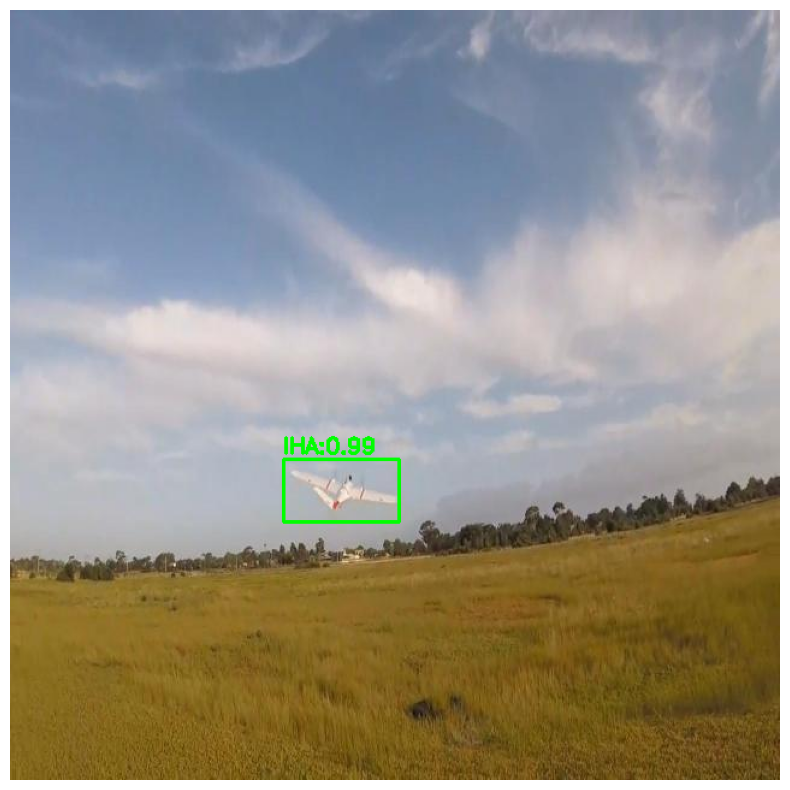

In [26]:
# 1. Önce Kernel'i durdurduğunuzdan emin olun.
# 2. En son kaydedilen checkpoint'i yükleyelim (Epoch 15)

from transformers import DetrForObjectDetection

print("Epoch 15 Modeli Yükleniyor...")

# Kaydettiğiniz klasörün tam adını buraya yazın (klasör yapınızda görünüyor olmalı)
checkpoint_path = "./detr-finetuned-epoch-15" 

try:
    model = DetrForObjectDetection.from_pretrained(
        checkpoint_path,
        num_labels=num_classes, # num_classes değişkeni hafızada olmalı (yoksa 4 yazın)
        ignore_mismatched_sizes=True,
        low_cpu_mem_usage=False
    )
    model.to(device)
    print("✅ Model başarıyla yüklendi. Teste hazır.")
except OSError:
    print("❌ Belirtilen klasör bulunamadı. Lütfen klasör adını kontrol edin.")

# Yüklendiyse hemen test edelim (Görsel Tahmin Kodu)
# (Burada predict_one fonksiyonunu tekrar çağırmanıza gerek yok, hafızadaysa direkt kullanın)
# Eğer hafızada değilse önceki predict_one kodunu tekrar çalıştırın.

import os
import random

if 'predict_one' in globals():
    # Rastgele bir validasyon resmi seç
    val_img_ids = coco_val.getImgIds()
    img_id = random.choice(val_img_ids)
    img_info = coco_val.loadImgs([img_id])[0]
    img_path = os.path.join(VAL_IMG_DIR, img_info['file_name'])
    
    print(f"Test Edilen: {img_path}")
    predict_one(img_path, score_thresh=0.5)
else:
    print("Lütfen önce 'predict_one' fonksiyonunu içeren hücreyi çalıştırın.")

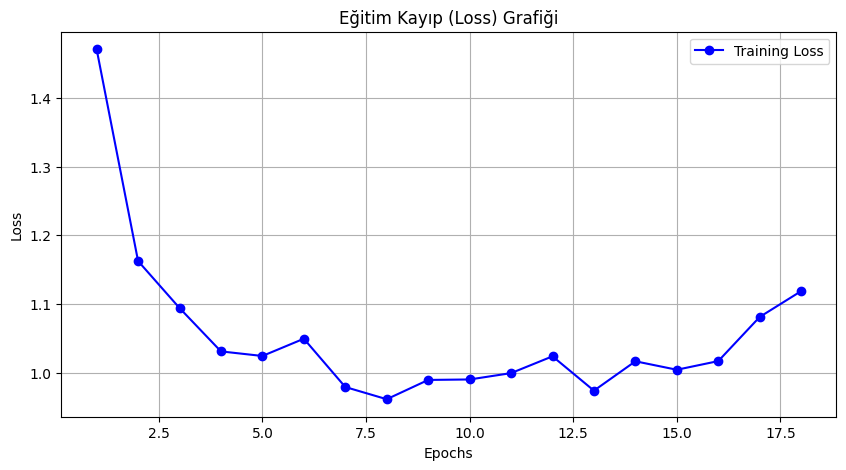

Validasyon seti üzerinde mAP hesaplanıyor (Bu işlem biraz zaman alır)...


Evaluating: 100%|██████████| 450/450 [03:13<00:00,  2.33it/s]


Loading and preparing results...
DONE (t=0.33s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=6.03s).
Accumulating evaluation results...
DONE (t=0.97s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.285
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.670
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.187
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.207
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.289
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.493
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.272
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.417
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.484
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [27]:
import matplotlib.pyplot as plt
from pycocotools.cocoeval import COCOeval
import json
import numpy as np

# --- A. LOSS GRAFİĞİ ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, 'b-o', label='Training Loss')
plt.title('Eğitim Kayıp (Loss) Grafiği')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

# --- B. mAP HESAPLAMA (COCO EVAL) ---
print("Validasyon seti üzerinde mAP hesaplanıyor (Bu işlem biraz zaman alır)...")

model.eval()
results = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating"):
        pixel_values = batch['pixel_values'].to(device)
        pixel_mask = batch['pixel_mask'].to(device)
        
        # Model tahmini
        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)
        
        # Orijinal boyutlara döndürme
        orig_target_sizes = torch.stack([t["orig_size"] for t in batch['labels']], dim=0).to(device)
        processed_outputs = image_processor.post_process_object_detection(
            outputs, target_sizes=orig_target_sizes, threshold=0.0
        )
        
        # Sonuçları COCO formatına çevir
        # batch['labels'] içindeki image_id'leri almamız lazım
        for idx, (output, target) in enumerate(zip(processed_outputs, batch['labels'])):
            image_id = target['image_id'].item()
            
            boxes = output['boxes'].cpu().numpy()
            scores = output['scores'].cpu().numpy()
            labels = output['labels'].cpu().numpy()
            
            for box, score, label in zip(boxes, scores, labels):
                # Box formatı: [x_min, y_min, x_max, y_max] -> [x, y, w, h] (COCO ister)
                x_min, y_min, x_max, y_max = box
                w, h = x_max - x_min, y_max - y_min
                
                # Sınıf ID'sini geri çevir (Model 0,1,2... -> Gerçek COCO ID)
                # Eğer cat_id_list globalde yoksa label'ı direkt kullanırız
                category_id = cat_id_list[label] if 'cat_id_list' in globals() else label
                
                results.append({
                    'image_id': image_id,
                    'category_id': int(category_id),
                    'bbox': [x_min, y_min, w, h],
                    'score': float(score)
                })

# Eğer sonuç varsa değerlendir
if len(results) > 0:
    coco_dt = coco_val.loadRes(results)
    coco_eval = COCOeval(coco_val, coco_dt, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    print("\nSonuç Yorumu: AP (IoU=0.50:0.95) genel başarıyı, AP (IoU=0.50) gevşek başarıyı gösterir.")
else:
    print("Model validasyon setinde hiç nesne tespit edemedi (Threshold çok yüksek olabilir mi?).")

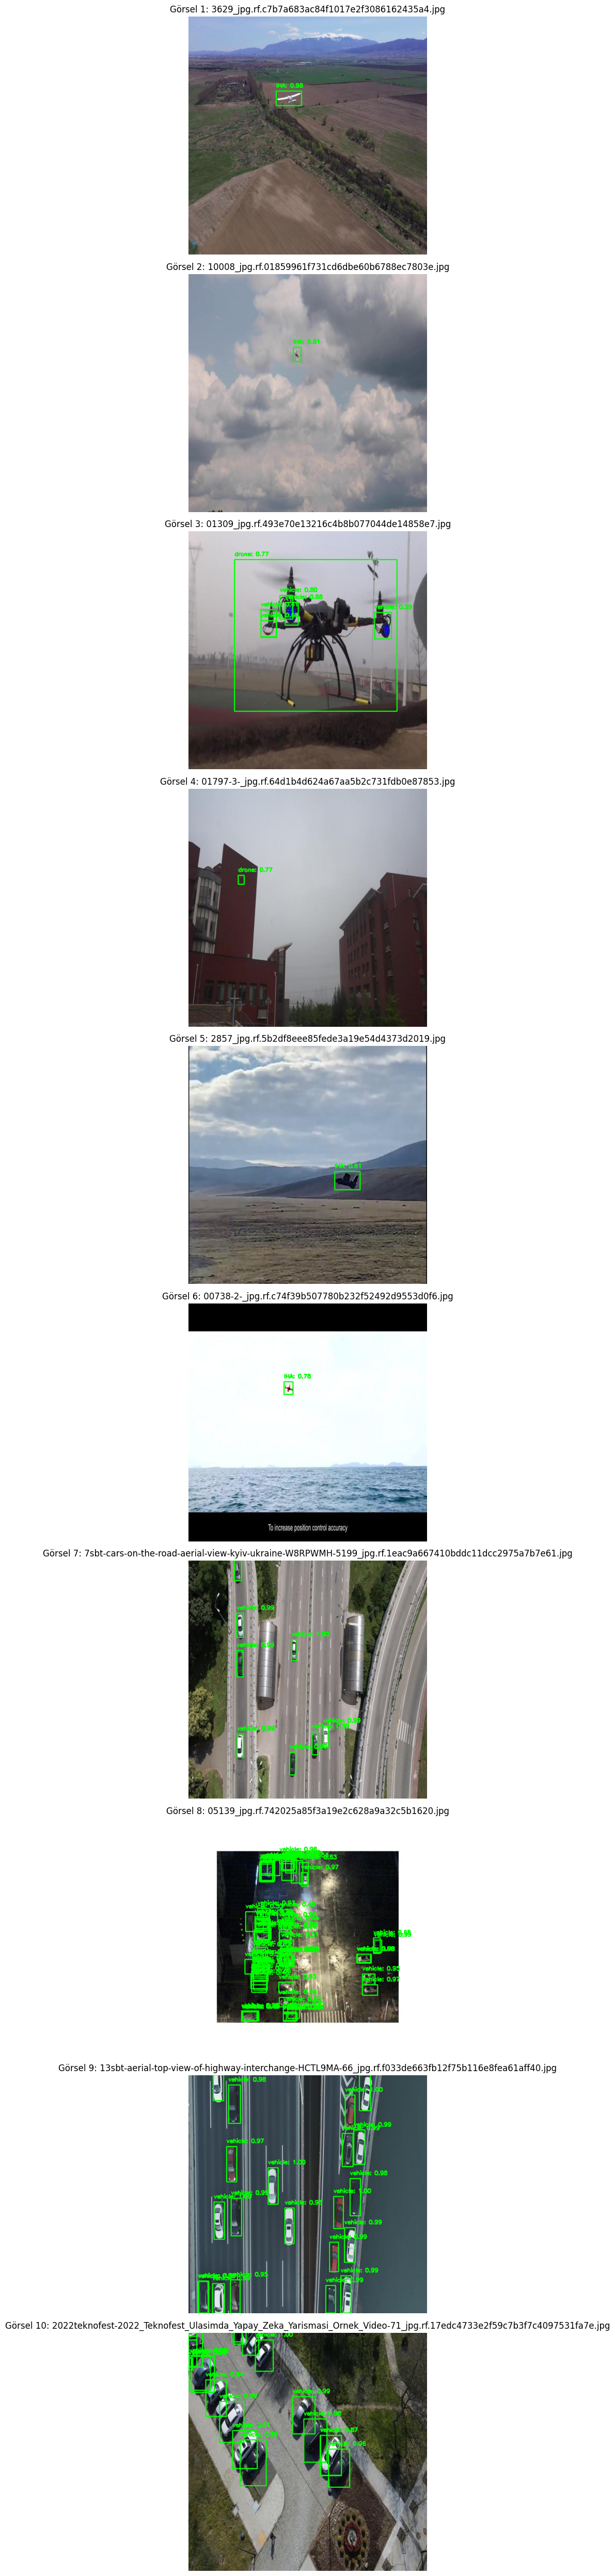

In [28]:
import random
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Ayarlar
NUM_IMAGES_TO_TEST = 10
CONFIDENCE_THRESHOLD = 0.4 # Güven eşiği (Düşürürseniz daha çok kutu çıkar)

# Val setinden rastgele resimler seç
all_val_ids = coco_val.getImgIds()
selected_ids = random.sample(all_val_ids, min(NUM_IMAGES_TO_TEST, len(all_val_ids)))

plt.figure(figsize=(15, 5 * NUM_IMAGES_TO_TEST))

for idx, img_id in enumerate(selected_ids):
    # Resmi yükle
    img_info = coco_val.loadImgs([img_id])[0]
    img_path = os.path.join(VAL_IMG_DIR, img_info['file_name'])
    image = Image.open(img_path).convert("RGB")
    
    # Tahmin
    inputs = image_processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]], device=device)
    results = image_processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=CONFIDENCE_THRESHOLD)[0]

    # Çizim hazırlığı
    img_np = np.array(image)
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        box = [int(i) for i in box.tolist()]
        label_text = id2name[label.item()] if 'id2name' in globals() else str(label.item())
        
        # Kutu Çiz
        cv2.rectangle(img_bgr, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
        # Etiket Yaz
        text = f"{label_text}: {score:.2f}"
        cv2.putText(img_bgr, text, (box[0], box[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Subplot'a ekle
    plt.subplot(NUM_IMAGES_TO_TEST, 1, idx + 1)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Görsel {idx+1}: {img_info['file_name']}")

plt.tight_layout()
plt.show()